In [ ]:
from PIL import Image
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


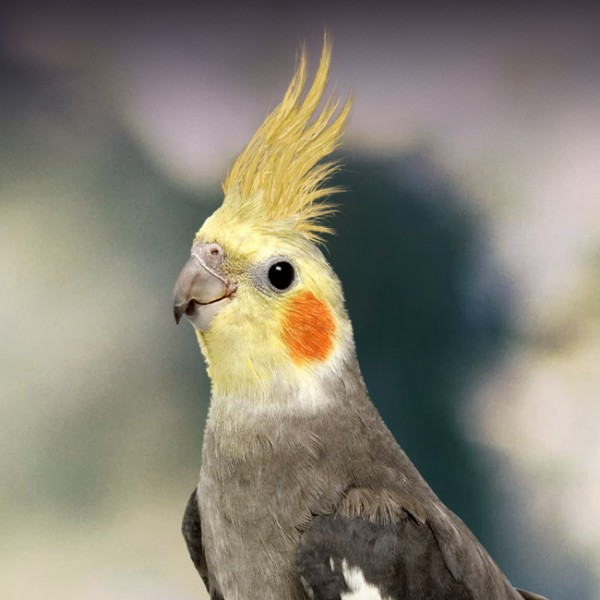

In [ ]:
"""1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image."""
image = Image.open("/content/drive/MyDrive/college/sem6/AI&ML/Workshops/Data/sample_image.jpg")
display(image)

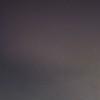

In [ ]:
"""Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing."""
image_array = np.array(image)
# print(image_array)
top_left_corner_array = image_array[:100, :100]
top_left_corner_image = Image.fromarray(top_left_corner_array)
display(top_left_corner_image)

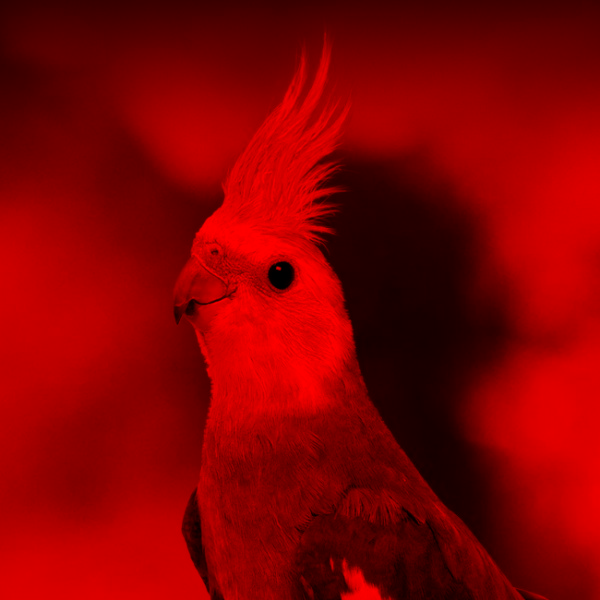

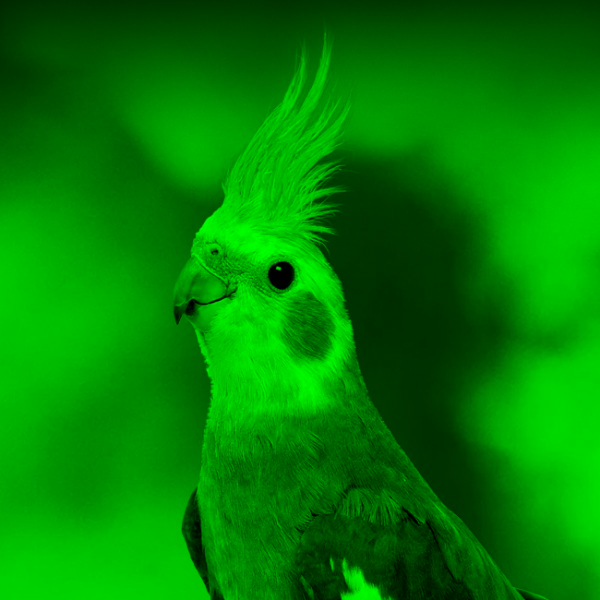

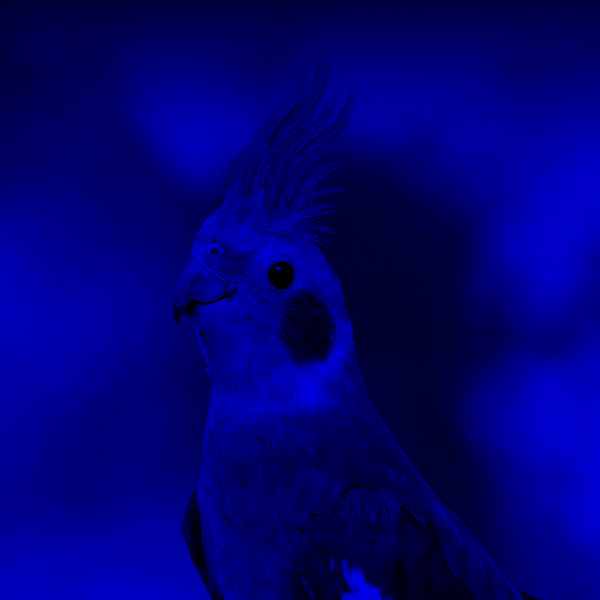

In [ ]:
"""Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}"""
r, g, b = np.zeros_like(image_array), np.zeros_like(image_array), np.zeros_like(image_array)
image_array = np.array(image)
r[:,:,0] = image_array[:, :, 0]
g[:,:,1] = image_array[:, :, 1]
b[:,:,2] = image_array[:, :, 2]
display(Image.fromarray(r))
display(Image.fromarray(g))
display(Image.fromarray(b))

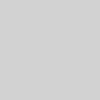

In [ ]:
top_left_corner_array[:] = 210
display(Image.fromarray(top_left_corner_array))

[[ 42  42  42 ...  57  57  58]
 [ 43  43  43 ...  57  57  58]
 [ 43  44  44 ...  57  57  57]
 ...
 [208 208 208 ... 141 144 147]
 [208 208 208 ... 141 143 146]
 [208 208 208 ... 140 143 145]]


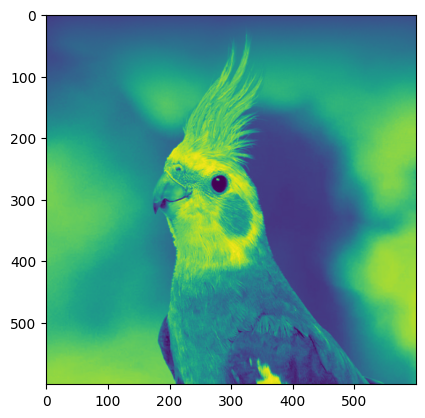

In [ ]:
import matplotlib.pyplot as plt
grayscale = image.convert('L')
grayscale_array = np.array(grayscale)
print(grayscale_array)
plt.imshow(grayscale)

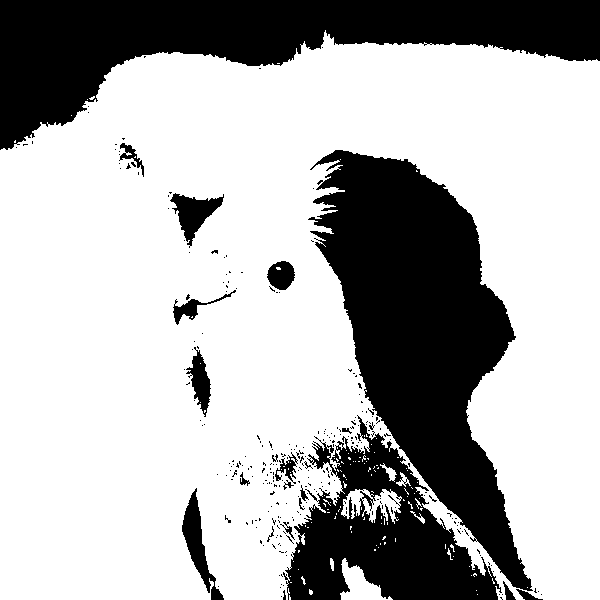

In [ ]:
binary_image_array = np.where(grayscale_array < 100, 0, 255).astype(np.uint8)
binary_image = Image.fromarray(binary_image_array)
display(binary_image)

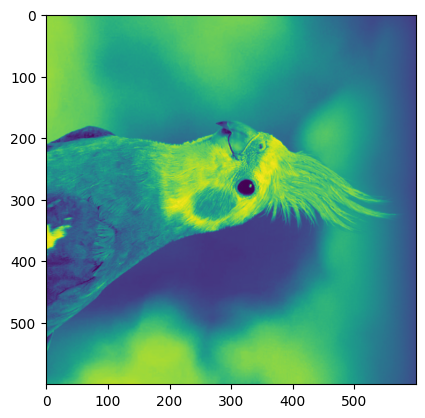

In [ ]:
rotated = grayscale.rotate(-90)
plt.imshow(rotated)

array([[[ 42,  42,  42],
        [ 42,  42,  42],
        [ 42,  42,  42],
        ...,
        [ 57,  57,  57],
        [ 57,  57,  57],
        [ 58,  58,  58]],

       [[ 43,  43,  43],
        [ 43,  43,  43],
        [ 43,  43,  43],
        ...,
        [ 57,  57,  57],
        [ 57,  57,  57],
        [ 58,  58,  58]],

       [[ 43,  43,  43],
        [ 44,  44,  44],
        [ 44,  44,  44],
        ...,
        [ 57,  57,  57],
        [ 57,  57,  57],
        [ 57,  57,  57]],

       ...,

       [[208, 208, 208],
        [208, 208, 208],
        [208, 208, 208],
        ...,
        [141, 141, 141],
        [144, 144, 144],
        [147, 147, 147]],

       [[208, 208, 208],
        [208, 208, 208],
        [208, 208, 208],
        ...,
        [141, 141, 141],
        [143, 143, 143],
        [146, 146, 146]],

       [[208, 208, 208],
        [208, 208, 208],
        [208, 208, 208],
        ...,
        [140, 140, 140],
        [143, 143, 143],
        [145, 145, 145]]], dtype=uint8)
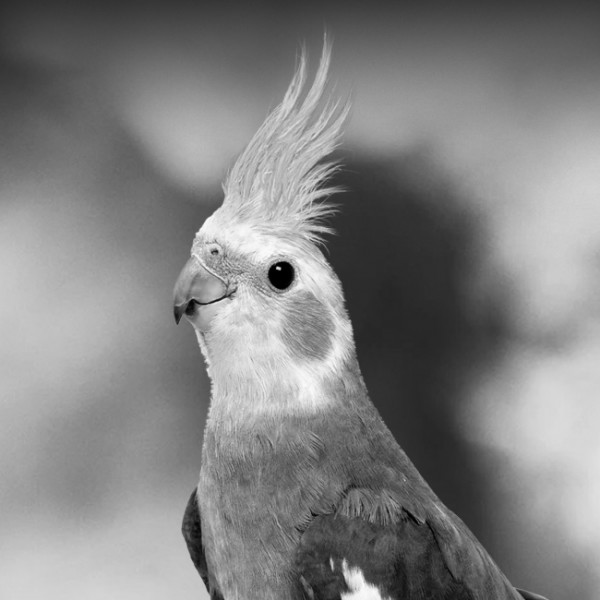

In [ ]:
rgb_image = np.dstack((grayscale_array, grayscale_array, grayscale_array))
display(rgb_image)

In [ ]:
height, width = grayscale_array.shape
data = grayscale_array.reshape(height,width)
# print(data)
mean = np.mean(data,axis = 0)
centered_data = data - mean
cov_matrix = np.cov(centered_data, rowvar= False)

In [ ]:
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

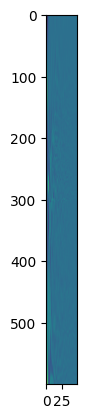

In [ ]:
k = 50 # selecting top k components
selected_vectors = eigenvectors[:,:k]
#Projection
low_dim_data = np.dot(centered_data, selected_vectors)

plt.imshow(low_dim_data)

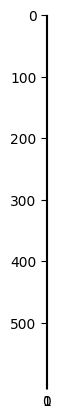

In [ ]:
# Calculate individual and cumulative variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Find 'k' for specific variance targets (e.g., 50%, 80%, 95%, 99%)
targets = [0.50, 0.80, 0.95, 0.99]
k_values = [np.argmax(cumulative_variance >= t) + 1 for t in targets]

experiment_vector_a = eigenvectors[:,:k_values[0]]
low_dim_data_a = np.dot(centered_data, experiment_vector_a)
plt.imshow(low_dim_data_a)

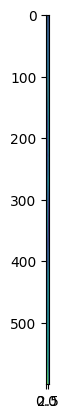

In [ ]:
experiment_vector_b = eigenvectors[:,:k_values[1]]
low_dim_data_b = np.dot(centered_data, experiment_vector_b)
plt.imshow(low_dim_data_b)

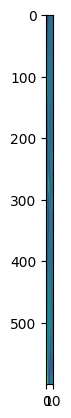

In [ ]:
experiment_vector_c = eigenvectors[:,:k_values[2]]
low_dim_data_c = np.dot(centered_data, experiment_vector_c)
plt.imshow(low_dim_data_c)

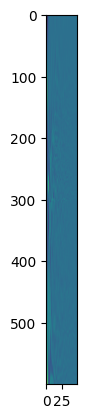

In [ ]:
experiment_vector_d = eigenvectors[:,:k_values[3]]
low_dim_data_d = np.dot(centered_data, experiment_vector_d)
plt.imshow(low_dim_data_d)